04/02/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

/opt/conda/lib/python3.8/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:132: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


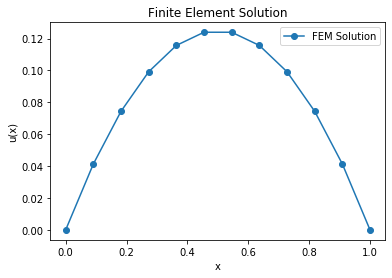

In [2]:
# Solving a Simple Boundary Value Problem:
# u′′(x)=−f(x) with u(0) = u(1) = 0

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# Problem setup
L = 1 # Length of the domain
N = 10 # Number of elements
h = L / (N + 1) # Element size

# Source term
f = np.ones(N)

# Assemble the system matrix
diagonals = [[-2] * N, [1] * (N - 1), [1] * (N - 1)]
A = diags(diagonals, [0, -1, 1]) / h**2

# Solve for u in Au = -f
u = spsolve(A, -f)

# Add boundary values (Dirichlet condition u(0) = u(1) = 0)
u = np.concatenate(([0], u, [0]))

# Plot the solution
x = np.linspace(0, L, N + 2)
plt.plot(x, u, 'o-', label='FEM Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Finite Element Solution')
plt.legend()
plt.show()

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


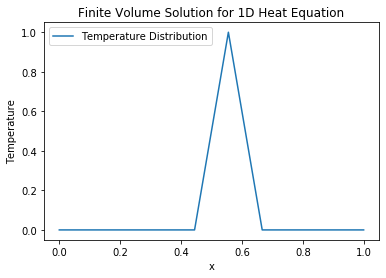

In [3]:
# 1D Heat Equation (Conservation of Heat)
# discretized spatially with FVM (Finite Volume Method)

# Parameters
alpha = 0.01 # Diffusion coefficient
dx = 0.1
dt = 0.01
L = 1.0
Nx = int(L / dx)
u = np.zeros(Nx) # Initial temperature distribution
u[int(Nx/2)] = 1.0 # Initial heat at the center

print(u)

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

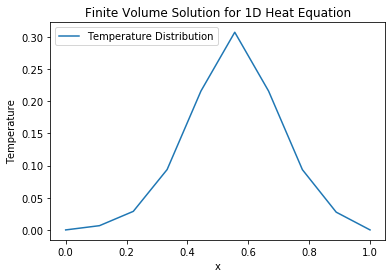

In [4]:
# FVM discretization loop
for n in range(100):
    u_new = u.copy()
    for i in range(1, Nx - 1):
        u_new[i] = u[i] + alpha * dt / dx**2 * (u[i + 1] - 2 * u[i] + u[i - 1])
    u = u_new

# Plot the final temperature distribution
x = np.linspace(0, L, Nx)
plt.plot(x, u, label='Temperature Distribution')
plt.xlabel('x')
plt.ylabel('Temperature')
plt.title('Finite Volume Solution for 1D Heat Equation')
plt.legend()
plt.show()

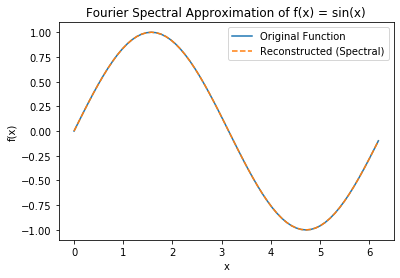

In [13]:
# Fourier Spectral Method: approximate sin(x)

from scipy.fftpack import fft, ifft


# Sample the function on a periodic domain
N = 64
x = np.linspace(0, 2 * np.pi, N, endpoint=False)
f = np.sin(x)

# Compute Fourier transform and reconstruct
f_hat = fft(f)
f_reconstructed = ifft(f_hat).real

# Plot the original and reconstructed function
plt.plot(x, f, label='Original Function')
plt.plot(x, f_reconstructed, '--', label='Reconstructed (Spectral)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Fourier Spectral Approximation of f(x) = sin(x)')
plt.legend()
plt.show()

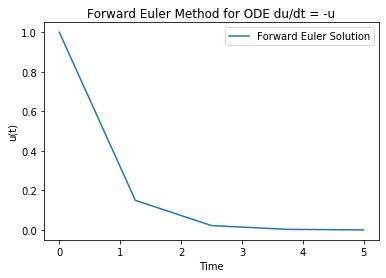

In [12]:
# Euler's Method

# Define parameters
T = 5.0  # Final time
dt = 0.85  # Time step *increasing makes line more jagged
N = int(T / dt)
u = np.zeros(N)
u[0] = 1  # Initial condition

# Time-stepping loop
for n in range(1, N):
    u[n] = u[n-1] - dt * u[n-1]

# Plot the solution
t = np.linspace(0, T, N)
plt.plot(t, u, label='Forward Euler Solution')
plt.xlabel('Time')
plt.ylabel('u(t)')
plt.title('Forward Euler Method for ODE du/dt = -u')
plt.legend()
plt.show()

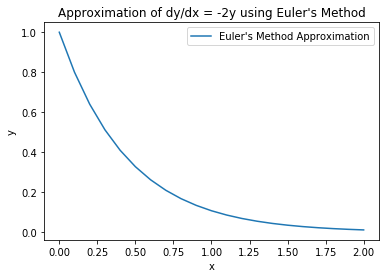

In [14]:
# Solving a Simple ODE using Finite Differences

import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h = 0.1  # step size
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

# Initial condition
y_values[0] = 1  # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

# Plot the results
plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()


Step size = 0.06
Error:
 [0.         0.0002     0.         0.000592   0.00156816 0.0029208
 0.00464238 0.00449353 0.00455502 0.00496376 0.00571281 0.00679535
 0.00820472 0.00809695 0.00804962 0.0083099  0.00887164 0.00972881
 0.01087549 0.01080047 0.01066896 0.01080995 0.01121798 0.01188771
 0.01281391 0.0127648  0.01256947 0.01261553 0.01289815 0.0134126
 0.01415423 0.01412542 0.01388302 0.01385445 0.01403543 0.01442177
 0.01500937 0.01499627 0.01472049 0.01463414 0.01473341 0.0150146
 0.01547408 0.01547296 0.01517494 0.01504472 0.01507894 0.01527431
 0.01562761 0.01563546 0.01532419 0.01516156 0.0151446  0.01527039
 0.01553608 0.01555047 0.01523313 0.01504747 0.01499084 0.01506067
 0.01525443 0.01527341 0.01495569 0.01475461 0.01466783 0.01469308
 0.01482811 0.01485016 0.01453649 0.01432614 0.01421706 0.01420721
 0.01429461 0.0143185  0.01401229 0.0137976  0.01367262 0.01363554
 0.01368462 0.01370941 0.01341321 0.01319808 0.01306242 0.01300463
 0.01302315 0.01304813 0.01276379 0.012

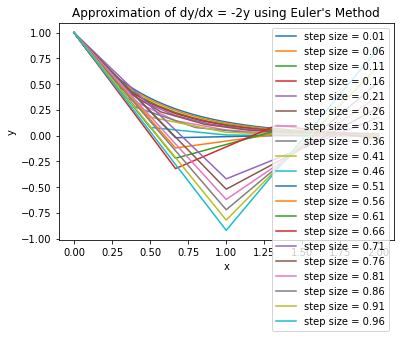

In [15]:
# CH15

# Define parameters
h = np.arange(0.01, 1.01, 0.05)  # step size

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# first step-size only=
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h[0])
x_first = np.linspace(x_start, x_end, num_steps + 1)
y_first = np.zeros(num_steps + 1)

# Initial condition
y_first[0] = 1  # y(0) = 1

# Implement Euler's method
for i in range(num_steps):
    y_first[i + 1] = y_first[i] + h[0] * f(x_first[i], y_first[i])
    
# Plot the results
plt.plot(x_first, y_first, label="step size = 0.01")
             
        
# remaining step-sizes        
for j in range (1, len(h)):
    print("\nStep size =", f"{h[j]:.2f}")
    
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h[j])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h[j] * f(x_values[i], y_values[i])
    
    # Plot the results
    plt.plot(x_values, y_values, label=f"step size = {h[j]:.2f}")
    
    # Calculate error
    y = np.interp(x_first, x_values, y_values)
    error = np.abs(y - y_first)
    totalError = np.sum(error)
        
    print("Error:\n", error)
    print("Total accumulated error =", totalError,"\n")
    

# Plot of all step-size runs
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()


Step size = 0.06
Error:
 [0.         0.00476863 0.00841438 0.01113557 0.01309937 0.01444644
 0.01529476 0.01574313 0.01587395 0.01575579 0.01544546 0.01498986
 0.01442748 0.01378979 0.01310232 0.01238562 0.0116561  0.01092826
 0.01021165 0.00951235 0.00883622 0.00818748 0.00756906 0.00698281
 0.00642971 0.0059101  0.00542373 0.00497    0.00454795 0.00415641
 0.00379404 0.0034594  0.00315099 0.00286726]
Total accumulated error = 0.317266079371714 


Step size = 0.11
Error:
 [0.         0.01895195 0.02992105 0.03543077 0.03729508 0.03680555
 0.03487111 0.03212206 0.02898716 0.02575063 0.02259889 0.0196348
 0.01691883 0.01447767 0.01231579 0.01042362 0.00878326 0.0073724
 0.00616698]
Total accumulated error = 0.3988276185511421 


Step size = 0.16
Error:
 [0.         0.03414708 0.04758277 0.04973768 0.04625696 0.04032691
 0.03375207 0.02747998 0.02191737 0.01720892 0.01335123 0.01025546
 0.00781317]
Total accumulated error = 0.34982960701089383 


Step size = 0.21
Error:
 [0.         0.0

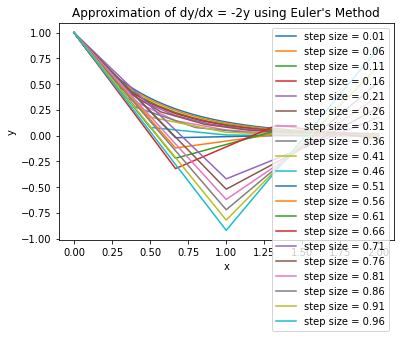

In [16]:
# Define parameters
h = np.arange(0.01, 1.01, 0.05)  # step size

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# first step-size only=
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h[0])
x_first = np.linspace(x_start, x_end, num_steps + 1)
y_first = np.zeros(num_steps + 1)

# Initial condition
y_first[0] = 1  # y(0) = 1

# Implement Euler's method
for i in range(num_steps):
    y_first[i + 1] = y_first[i] + h[0] * f(x_first[i], y_first[i])
    
# Plot the results
plt.plot(x_first, y_first, label="step size = 0.01")
             
        
# remaining step-sizes        
for j in range (1, len(h)):
    print("\nStep size =", f"{h[j]:.2f}")
    
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h[j])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h[j] * f(x_values[i], y_values[i])
    
    # Plot the results
    plt.plot(x_values, y_values, label=f"step size = {h[j]:.2f}")
    
    # Calculate error
    y = np.interp(x_values, x_first, y_first)
    error = np.abs(y_values - y)
    totalError = np.sum(error)
        
    print("Error:\n", error)
    print("Total accumulated error =", totalError,"\n")
    

# Plot of all step-size runs
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()


Euler's Method Approximation with Step Size = 0.01


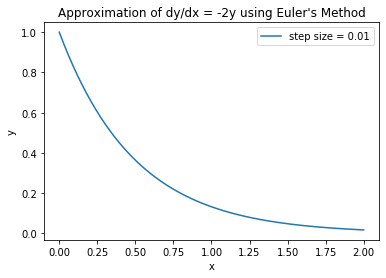


Euler's Method Approximation with Step Size = 0.060000000000000005


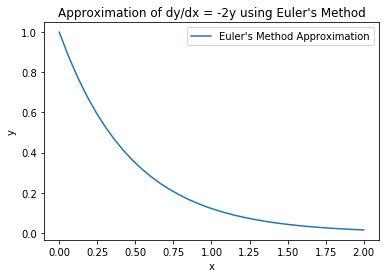

7.238335810831134
Total accumulated error = 37.96879955618294 


Euler's Method Approximation with Step Size = 0.11


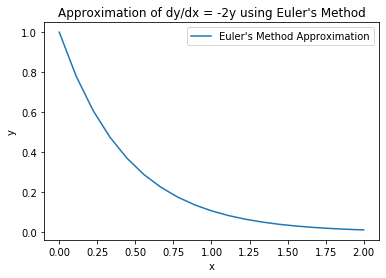

3.5138703824051722
Total accumulated error = 41.693264984608895 


Euler's Method Approximation with Step Size = 0.16000000000000003


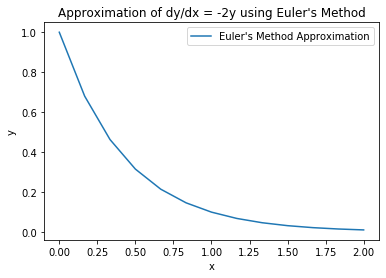

2.110875444171012
Total accumulated error = 43.09625992284305 


Euler's Method Approximation with Step Size = 0.21000000000000002


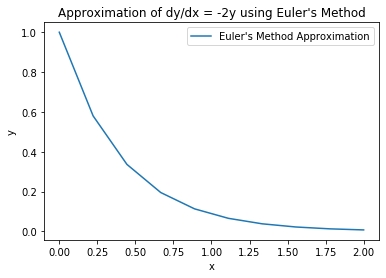

1.3750031799999602
Total accumulated error = 43.83213218701411 


Euler's Method Approximation with Step Size = 0.26


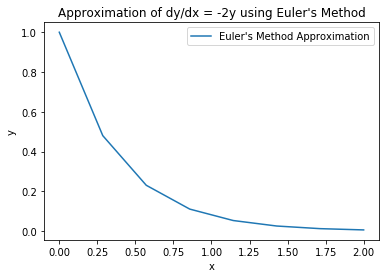

0.9204757587296255
Total accumulated error = 44.286659608284445 


Euler's Method Approximation with Step Size = 0.31000000000000005


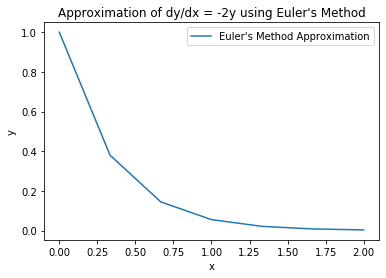

0.6122019690099196
Total accumulated error = 44.59493339800415 


Euler's Method Approximation with Step Size = 0.36000000000000004


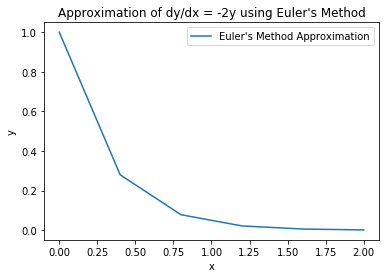

0.38870148710399977
Total accumulated error = 44.81843387991007 


Euler's Method Approximation with Step Size = 0.41000000000000003


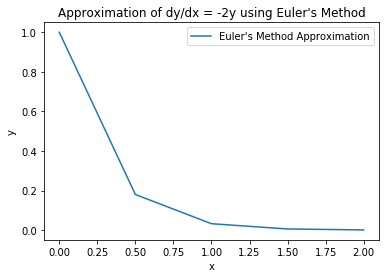

0.21947071679999994
Total accumulated error = 44.98766465021407 


Euler's Method Approximation with Step Size = 0.46


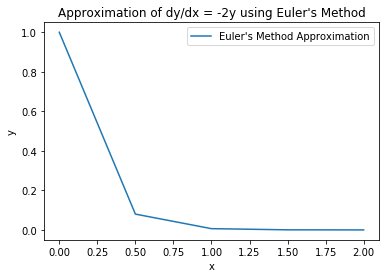

0.08695623679999995
Total accumulated error = 45.12017913021407 


Euler's Method Approximation with Step Size = 0.51


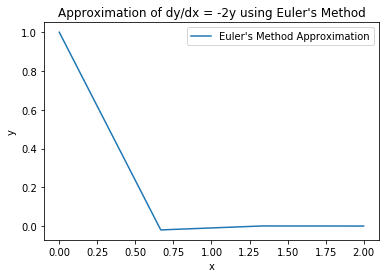

-0.01960784000000002
Total accumulated error = 45.18752752701407 


Euler's Method Approximation with Step Size = 0.56


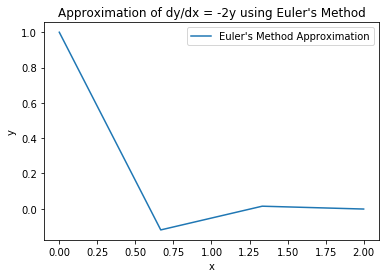

-0.10712064000000009
Total accumulated error = 45.10001472701407 


Euler's Method Approximation with Step Size = 0.6100000000000001


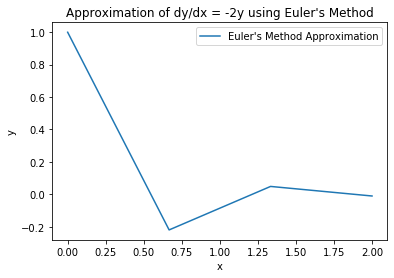

-0.1799054400000001
Total accumulated error = 45.02722992701407 


Euler's Method Approximation with Step Size = 0.66


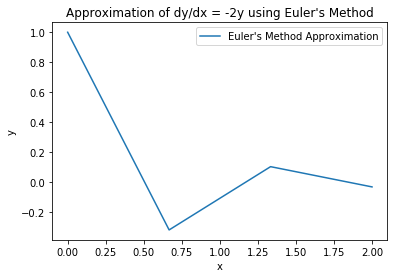

-0.23988224000000002
Total accumulated error = 44.96725312701407 


Euler's Method Approximation with Step Size = 0.7100000000000001


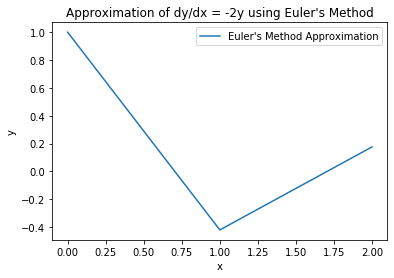

-0.31768800000000014
Total accumulated error = 44.88944736701407 


Euler's Method Approximation with Step Size = 0.76


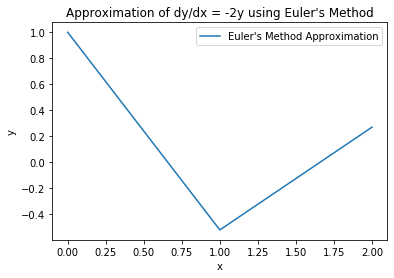

-0.39020800000000005
Total accumulated error = 44.81692736701407 


Euler's Method Approximation with Step Size = 0.81


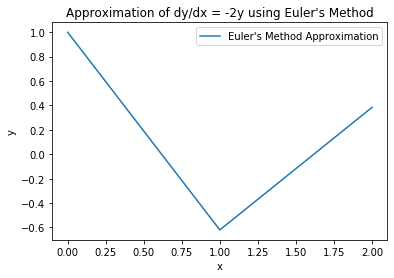

-0.4739280000000001
Total accumulated error = 44.73320736701407 


Euler's Method Approximation with Step Size = 0.8600000000000001


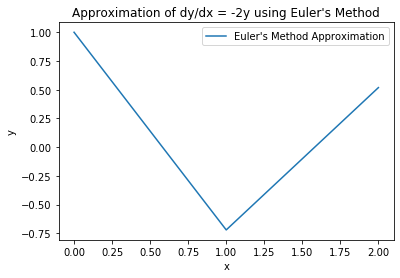

-0.5748480000000002
Total accumulated error = 44.632287367014065 


Euler's Method Approximation with Step Size = 0.91


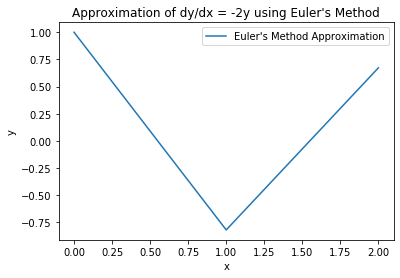

-0.698968
Total accumulated error = 44.50816736701407 


Euler's Method Approximation with Step Size = 0.9600000000000001


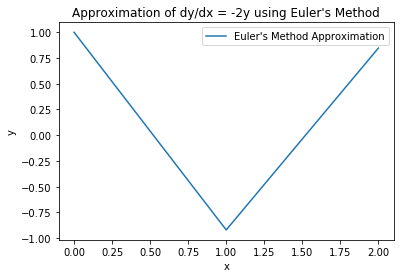

-0.8522880000000002
Total accumulated error = 44.35484736701407 



In [17]:
# Define parameters
h = np.arange(0.01, 1.01, 0.05)  # step size

# first step-size only
print("\nEuler's Method Approximation with Step Size =", h[0])

x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h[0])
x_first = np.linspace(x_start, x_end, num_steps + 1)
y_first = np.zeros(num_steps + 1)

# Initial condition
y_first[0] = 1  # y(0) = 1
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Implement Euler's method
for i in range(num_steps):
    y_first[i + 1] = y_first[i] + h[0] * f(x_first[i], y_first[i])
    
error1 = y_first + h[j] * f(x_first, y_first)
totalError1 = np.sum(error1)
    
# Plot the results
plt.plot(x_first, y_first, label="step size = 0.01")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()
    
         
        
# remaining step-sizes        
for j in range (1, len(h)):
    print("\nEuler's Method Approximation with Step Size =", h[j])
    
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h[j])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h[j] * f(x_values[i], y_values[i])
    
    error = y_values + h[j] * f(x_values, y_values)
    totalError = np.sum(error)
    
    # Plot the results
    plt.plot(x_values, y_values, label="Euler's Method Approximation")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximation of dy/dx = -2y using Euler's Method")
    plt.legend()
    plt.show()
    
    print(totalError)
    print("Total accumulated error =", abs(totalError1)-abs(totalError),"\n")